# Analísis de los Penales en la Historia de los Mundiales
- - - 
## Introducción
Los penales constituyen uno de los momentos más tensionantes y determinantes en el fútbol. Un único remate puede definir la eliminación o consagración de una selección en la Copa Mundial. En la final del Mundial 2022, Argentina se consagró como campeona mediante una tanda de penales contra la selección francesa. A lo largo de la historia de los mundiales se han ejecutado cientos de penales, tanto durante el tiempo reglamentario como en tandas de definición.
En este proyecto se analizaron los penales registrados en la historia con el objetivo de identificar patrones, tendencias y diferencias entre selecciones y jugadores.
## Objetivos
Analizar los penales ejecutados en la historia de los mundiales para identificar patrones estadísticos relacionados con la efectividad, la frecuencia y el contexto de ejecución. Tambien, hacer un acercamiento a las respuestas de estas preguntas:
- ¿EXISTE REALMENTE UNA VENTAJA PSICOLÓGICA PARA CIERTAS SELECCIONES EN LAS TANDAS DE PENALES? 
- ¿LA PRESIÓN DEL CONTEXTO AFECTA LA TASA DE CONVERSIÓN?
- ¿HAY "VERDADES" FUTBOLISTICAS RESPALDADAS POR DATOS ESTADISTICOS?
## Descripción de los datos
Para este proyecto se utilizaron tres conjuntos de datos en formato CSV (goals, matches y penalty_kicks) obtenidos de The Fjelstul WorldCup Database que se puede acceder desde este link: https://github.com/jfjelstul/worldcup/tree/master.
Los archivos contienen información sobre (por nombrar algunos):
- Penales ejecutados en la historia de los Mundiales.
- Resultados de tandas de penales.
- Información sobre jugadores y selecciones.
- - -

## Carga de librerías y datasets
Se importan las librerías necesarias para la manipulación de datos y la construcción de visualizaciones. A continuación se cargan los tres archivos CSV que contienen la información utilizada en el análisis. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

penales = pd.read_csv(r'C:\Users\USer\OneDrive\Documentos\Proyectos Data\Python\FIFA World Cup\Data\penalty_kicks.csv')
partidos = pd.read_csv(r'C:\Users\USer\OneDrive\Documentos\Proyectos Data\Python\FIFA World Cup\Data\matches.csv')
goles = pd.read_csv(r'C:\Users\USer\OneDrive\Documentos\Proyectos Data\Python\FIFA World Cup\Data\goals.csv')

## Exploración inicial
Antes de comenzar el análisis, se inspeccionará la estructura de los conjuntos de datos para conocer las variables disponibles y detectar posibles valores faltantes.

In [2]:
penales.head()

,key_id,penalty_kick_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,team_name,team_code,home_team,away_team,player_id,family_name,given_name,shirt_number,converted
0,1,PK-001,WC-1982,1982 FIFA Men's World Cup,M-1982-50,West Germany vs France,1982-07-08,semi-finals,not applicable,T-86,West Germany,DEU,1,0,P-68969,Kaltz,Manfred,20,1
1,2,PK-002,WC-1982,1982 FIFA Men's World Cup,M-1982-50,West Germany vs France,1982-07-08,semi-finals,not applicable,T-86,West Germany,DEU,1,0,P-48686,Breitner,Paul,3,1
2,3,PK-003,WC-1982,1982 FIFA Men's World Cup,M-1982-50,West Germany vs France,1982-07-08,semi-finals,not applicable,T-86,West Germany,DEU,1,0,P-45695,Stielike,Uli,15,0
3,4,PK-004,WC-1982,1982 FIFA Men's World Cup,M-1982-50,West Germany vs France,1982-07-08,semi-finals,not applicable,T-86,West Germany,DEU,1,0,P-89975,Littbarski,Pierre,7,1
4,5,PK-005,WC-1982,1982 FIFA Men's World Cup,M-1982-50,West Germany vs France,1982-07-08,semi-finals,not applicable,T-86,West Germany,DEU,1,0,P-59574,Rummenigge,Karl-Heinz,11,1


In [3]:
partidos.head()

,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


In [4]:
goles.head()

,key_id,goal_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,...,shirt_number,player_team_id,player_team_name,player_team_code,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty
0,1,G-0001,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,1930-07-13,group stage,Group 1,T-30,...,0,T-30,France,FRA,19',19,0,first half,0,0
1,2,G-0002,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,1930-07-13,group stage,Group 1,T-30,...,0,T-30,France,FRA,40',40,0,first half,0,0
2,3,G-0003,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,1930-07-13,group stage,Group 1,T-30,...,0,T-30,France,FRA,43',43,0,first half,0,0
3,4,G-0004,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,1930-07-13,group stage,Group 1,T-46,...,0,T-46,Mexico,MEX,70',70,0,second half,0,0
4,5,G-0005,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,1930-07-13,group stage,Group 1,T-30,...,0,T-30,France,FRA,87',87,0,second half,0,0


In [5]:
goles.info()
partidos.info()
penales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3637 entries, 0 to 3636
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   key_id             3637 non-null   int64 
 1   goal_id            3637 non-null   object
 2   tournament_id      3637 non-null   object
 3   tournament_name    3637 non-null   object
 4   match_id           3637 non-null   object
 5   match_name         3637 non-null   object
 6   match_date         3637 non-null   object
 7   stage_name         3637 non-null   object
 8   group_name         3637 non-null   object
 9   team_id            3637 non-null   object
 10  team_name          3637 non-null   object
 11  team_code          3637 non-null   object
 12  home_team          3637 non-null   int64 
 13  away_team          3637 non-null   int64 
 14  player_id          3637 non-null   object
 15  family_name        3637 non-null   object
 16  given_name         3637 non-null   object


In [6]:
penales.duplicated().sum()
partidos.duplicated().sum()
goles.duplicated().sum()

np.int64(0)

In [7]:
print("PENALES")
display(penales.describe(include="all"))

print("PARTIDOS")
display(partidos.describe(include="all"))

print("GOLES")
display(goles.describe(include="all"))

PENALES


,key_id,penalty_kick_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,team_name,team_code,home_team,away_team,player_id,family_name,given_name,shirt_number,converted
count,396.0000,396,396,396,396,396,396,396,396,396,396,396,396.000000,396.000000,396,396,396,396.000000,396.000000
unique,NaN,396,16,16,43,41,39,6,1,36,36,35,NaN,NaN,350,343,270,NaN,NaN
top,NaN,PK-001,WC-2022,2022 FIFA Men's World Cup,M-1982-50,Italy vs France,1999-07-10,quarter-finals,not applicable,T-30,France,FRA,NaN,NaN,P-14758,Messi,not applicable,NaN,NaN
freq,NaN,1,41,41,12,19,22,131,396,34,34,34,NaN,NaN,3,3,38,NaN,NaN
mean,198.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.500000,NaN,NaN,NaN,11.224747,0.707071
std,114.4596,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500633,0.500633,NaN,NaN,NaN,5.723369,0.455682
min,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,2.000000,0.000000
25%,99.7500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,7.000000,0.000000
50%,198.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,0.500000,NaN,NaN,NaN,10.000000,1.000000
75%,297.2500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,16.000000,1.000000


PARTIDOS


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
count,1248.000000,1248,1248,1248,1248,1248,1248,1248.000000,1248.000000,1248.000000,...,1248.000000,1248.000000,1248.000000,1248,1248.000000,1248.000000,1248,1248.000000,1248.000000,1248.000000
unique,NaN,30,30,1248,909,10,16,NaN,NaN,NaN,...,NaN,NaN,NaN,15,NaN,NaN,3,NaN,NaN,NaN
top,NaN,WC-2022,2022 FIFA Men's World Cup,M-1930-01,Brazil vs Sweden,group stage,not applicable,NaN,NaN,NaN,...,NaN,NaN,NaN,0-0,NaN,NaN,home team win,NaN,NaN,NaN
freq,NaN,64,64,1,8,880,332,NaN,NaN,NaN,...,NaN,NaN,NaN,1205,NaN,NaN,703,NaN,NaN,NaN
mean,624.500000,NaN,NaN,NaN,NaN,NaN,NaN,0.738782,0.261218,0.003205,...,-0.697917,0.070513,0.034455,NaN,0.118590,0.105769,NaN,0.563301,0.268429,0.168269
std,360.410877,NaN,NaN,NaN,NaN,NaN,NaN,0.439475,0.439475,0.056546,...,2.146053,0.256112,0.182468,NaN,0.664393,0.602080,NaN,0.496176,0.443320,0.374255
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,-13.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
25%,312.750000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,-2.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
50%,624.500000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,...,-1.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,1.000000,0.000000,0.000000
75%,936.250000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,...,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,1.000000,1.000000,0.000000


GOLES


,key_id,goal_id,tournament_id,tournament_name,match_id,match_name,match_date,stage_name,group_name,team_id,...,shirt_number,player_team_id,player_team_name,player_team_code,minute_label,minute_regulation,minute_stoppage,match_period,own_goal,penalty
count,3637.000000,3637,3637,3637,3637,3637,3637,3637,3637,3637,...,3637.000000,3637,3637,3637,3637,3637.000000,3637.000000,3637,3637.000000,3637.000000
unique,NaN,3637,30,30,1162,857,483,10,16,85,...,NaN,86,86,85,141,NaN,NaN,8,NaN,NaN
top,NaN,G-0001,WC-2022,2022 FIFA Men's World Cup,M-2019-12,Brazil vs Sweden,1934-05-27,group stage,not applicable,T-09,...,NaN,T-09,Brazil,DEU,75',NaN,NaN,second half,NaN,NaN
freq,NaN,1,172,172,13,33,43,2489,1054,303,...,NaN,305,305,348,59,NaN,NaN,1886,NaN,NaN
mean,1819.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.528732,NaN,NaN,NaN,NaN,51.168546,0.119879,NaN,0.021721,0.080286
std,1050.055792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.743036,NaN,NaN,NaN,NaN,27.388687,0.697263,NaN,0.145792,0.271773
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,0.000000,0.000000
25%,910.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.000000,NaN,NaN,NaN,NaN,27.000000,0.000000,NaN,0.000000,0.000000
50%,1819.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.000000,NaN,NaN,NaN,NaN,52.000000,0.000000,NaN,0.000000,0.000000
75%,2728.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.000000,NaN,NaN,NaN,NaN,75.000000,0.000000,NaN,0.000000,0.000000


Los 3 datasets están limpios. No presentan duplicados ni datos faltantes. Se utilizaron funciones como head() e info() para familiarizarse con las variables y sus tipo de datos. En resumen:
***penales:*** Tiene 19 variables de tipo numérico y objeto, con 396 registros.
***goles:*** Tiene 27 columnas, también de tipo numérico y objeto, con 3637 observaciones.
***partidos:*** Tiene un total de 37 variables con 1248 registros.
- - - 

## Limpieza y preparación de datos


In [8]:
display(penales["tournament_name"].unique())
display(partidos["tournament_name"].unique())
display(goles["tournament_name"].unique())

array(["1982 FIFA Men's World Cup", "1986 FIFA Men's World Cup",
       "1990 FIFA Men's World Cup", "1994 FIFA Men's World Cup",
       "1995 FIFA Women's World Cup", "1998 FIFA Men's World Cup",
       "1999 FIFA Women's World Cup", "2002 FIFA Men's World Cup",
       "2006 FIFA Men's World Cup", "2010 FIFA Men's World Cup",
       "2011 FIFA Women's World Cup", "2014 FIFA Men's World Cup",
       "2015 FIFA Women's World Cup", "2018 FIFA Men's World Cup",
       "2019 FIFA Women's World Cup", "2022 FIFA Men's World Cup"],
      dtype=object)

array(["1930 FIFA Men's World Cup", "1934 FIFA Men's World Cup",
       "1938 FIFA Men's World Cup", "1950 FIFA Men's World Cup",
       "1954 FIFA Men's World Cup", "1958 FIFA Men's World Cup",
       "1962 FIFA Men's World Cup", "1966 FIFA Men's World Cup",
       "1970 FIFA Men's World Cup", "1974 FIFA Men's World Cup",
       "1978 FIFA Men's World Cup", "1982 FIFA Men's World Cup",
       "1986 FIFA Men's World Cup", "1990 FIFA Men's World Cup",
       "1991 FIFA Women's World Cup", "1994 FIFA Men's World Cup",
       "1995 FIFA Women's World Cup", "1998 FIFA Men's World Cup",
       "1999 FIFA Women's World Cup", "2002 FIFA Men's World Cup",
       "2003 FIFA Women's World Cup", "2006 FIFA Men's World Cup",
       "2007 FIFA Women's World Cup", "2010 FIFA Men's World Cup",
       "2011 FIFA Women's World Cup", "2014 FIFA Men's World Cup",
       "2015 FIFA Women's World Cup", "2018 FIFA Men's World Cup",
       "2019 FIFA Women's World Cup", "2022 FIFA Men's World Cup"],
      dt

array(["1930 FIFA Men's World Cup", "1934 FIFA Men's World Cup",
       "1938 FIFA Men's World Cup", "1950 FIFA Men's World Cup",
       "1954 FIFA Men's World Cup", "1958 FIFA Men's World Cup",
       "1962 FIFA Men's World Cup", "1966 FIFA Men's World Cup",
       "1970 FIFA Men's World Cup", "1974 FIFA Men's World Cup",
       "1978 FIFA Men's World Cup", "1982 FIFA Men's World Cup",
       "1986 FIFA Men's World Cup", "1990 FIFA Men's World Cup",
       "1991 FIFA Women's World Cup", "1994 FIFA Men's World Cup",
       "1995 FIFA Women's World Cup", "1998 FIFA Men's World Cup",
       "1999 FIFA Women's World Cup", "2002 FIFA Men's World Cup",
       "2003 FIFA Women's World Cup", "2006 FIFA Men's World Cup",
       "2007 FIFA Women's World Cup", "2010 FIFA Men's World Cup",
       "2011 FIFA Women's World Cup", "2014 FIFA Men's World Cup",
       "2015 FIFA Women's World Cup", "2018 FIFA Men's World Cup",
       "2019 FIFA Women's World Cup", "2022 FIFA Men's World Cup"],
      dt

In [9]:
penales = penales[penales["tournament_name"].str.contains("Men's")]
goles = goles[goles["tournament_name"].str.contains("Men's")]
partidos = partidos[partidos["tournament_name"].str.contains("Men's")]

penales["match_date"] = pd.to_datetime(penales["match_date"])
goles["match_date"] = pd.to_datetime(goles["match_date"])
partidos["match_date"] = pd.to_datetime(partidos["match_date"])

penales["year"] = penales["tournament_name"].str[:4].astype(int)
goles["year"] = goles["tournament_name"].str[:4].astype(int)
partidos["year"] = partidos["tournament_name"].str[:4].astype(int)

display(penales.info())

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 0 to 395
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   key_id           320 non-null    int64         
 1   penalty_kick_id  320 non-null    object        
 2   tournament_id    320 non-null    object        
 3   tournament_name  320 non-null    object        
 4   match_id         320 non-null    object        
 5   match_name       320 non-null    object        
 6   match_date       320 non-null    datetime64[ns]
 7   stage_name       320 non-null    object        
 8   group_name       320 non-null    object        
 9   team_id          320 non-null    object        
 10  team_name        320 non-null    object        
 11  team_code        320 non-null    object        
 12  home_team        320 non-null    int64         
 13  away_team        320 non-null    int64         
 14  player_id        320 non-null    object        

None

In [10]:
penales["stage_name"] = penales["stage_name"].astype("category")
penales["group_name"] = penales["group_name"].astype("category")
penales["team_name"] = penales["team_name"].astype("category")
penales["converted"] = penales["converted"].astype("bool")

goles["player_name"] = (
    goles["given_name"] + 
    " " + 
    goles["family_name"]
)

penales["player_name"] = (
    penales["given_name"] + 
    " " + 
    penales["family_name"]
)

goles["stage_name"] = goles["stage_name"].astype("category")
goles["group_name"] = goles["group_name"].astype("category")
goles["team_name"] = goles["team_name"].astype("category")
goles["match_period"] = goles["match_period"].astype("category")
goles["own_goal"] = goles["own_goal"].astype("bool")
goles["penalty"] = goles["penalty"].astype("bool")

partidos["group_name"] = partidos["group_name"].astype("str")
partidos["group_stage"] = partidos["group_stage"].astype("bool")
partidos["knockout_stage"] = partidos["knockout_stage"].astype("bool")
partidos["extra_time"] = partidos["extra_time"].astype("bool")
partidos["penalty_shootout"] = partidos["penalty_shootout"].astype("bool")
partidos["home_team_win"] = partidos["home_team_win"].astype("bool")
partidos["away_team_win"] = partidos["away_team_win"].astype("bool")
partidos["draw"] = partidos["draw"].astype("bool")


In [11]:
display(penales.info())
display(goles.info())
display(partidos.info())

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 0 to 395
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   key_id           320 non-null    int64         
 1   penalty_kick_id  320 non-null    object        
 2   tournament_id    320 non-null    object        
 3   tournament_name  320 non-null    object        
 4   match_id         320 non-null    object        
 5   match_name       320 non-null    object        
 6   match_date       320 non-null    datetime64[ns]
 7   stage_name       320 non-null    category      
 8   group_name       320 non-null    category      
 9   team_id          320 non-null    object        
 10  team_name        320 non-null    category      
 11  team_code        320 non-null    object        
 12  home_team        320 non-null    int64         
 13  away_team        320 non-null    int64         
 14  player_id        320 non-null    object        

None

<class 'pandas.core.frame.DataFrame'>
Index: 2720 entries, 0 to 3636
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   key_id             2720 non-null   int64         
 1   goal_id            2720 non-null   object        
 2   tournament_id      2720 non-null   object        
 3   tournament_name    2720 non-null   object        
 4   match_id           2720 non-null   object        
 5   match_name         2720 non-null   object        
 6   match_date         2720 non-null   datetime64[ns]
 7   stage_name         2720 non-null   category      
 8   group_name         2720 non-null   category      
 9   team_id            2720 non-null   object        
 10  team_name          2720 non-null   category      
 11  team_code          2720 non-null   object        
 12  home_team          2720 non-null   int64         
 13  away_team          2720 non-null   int64         
 14  player_id    

None

<class 'pandas.core.frame.DataFrame'>
Index: 964 entries, 0 to 1247
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   key_id                     964 non-null    int64         
 1   tournament_id              964 non-null    object        
 2   tournament_name            964 non-null    object        
 3   match_id                   964 non-null    object        
 4   match_name                 964 non-null    object        
 5   stage_name                 964 non-null    object        
 6   group_name                 964 non-null    object        
 7   group_stage                964 non-null    bool          
 8   knockout_stage             964 non-null    bool          
 9   replayed                   964 non-null    int64         
 10  replay                     964 non-null    int64         
 11  match_date                 964 non-null    datetime64[ns]
 12  match_time  

None

#### Limitaciones de los datos
El dataset específico de penales contiene únicamente los lanzamientos correspondientes a tandas de definición y comienza en el Mundial de 1982. Por otra parte, la información sobre goles de penal durante el desarrollo del partido está disponible para todas las ediciones del torneo. En consecuencia, los análisis relacionados con tandas de penales se restringen al período 1982-2022. 
Se realizaron conversiones en los tipos de datos para facilitar los análisis posteriores. Las variables temporales se transformaron al formato fecha, las variables categóricas se almacenaron como categorías y las variables binarias se representan como booleanos. Esto permite trabajar de manera más eficiente y mejora la interpretación de los resultados. 
También, los datasets no solo contenían los registros correspondientes a la FIFA Men's World Cup, sino que además tenían la información de los torneos femeninos. Debido a que este análisis se inició de cara a la edición 2026 del campeonato, se restringe a los registros atribuidos a los torneos masculinos.


- - -
## Panorama general de los penales


In [12]:
goles_totales = len(goles)
goles_penal = goles["penalty"].sum()
goles_no_penal = goles_totales - goles_penal

tabla_penales_partido = pd.DataFrame({
    "Tipo de gol":["De jugada","De penal","Total"],
    "Cantidad":[goles_no_penal, goles_penal, goles_totales],
    "Porcentaje":[goles_no_penal/goles_totales * 100, goles_penal/goles_totales * 100, 100]
})

tabla_penales_partido["Porcentaje"] = tabla_penales_partido["Porcentaje"].round(2).astype(str) + "%"

print(tabla_penales_partido)

  Tipo de gol  Cantidad Porcentaje
0   De jugada      2506     92.13%
1    De penal       214      7.87%
2       Total      2720     100.0%


In [13]:
penales_tandas = partidos["penalty_shootout"].sum()
total_kicks = len(penales)
cantidad_conversiones = penales["converted"].sum()
cantidad_fallos = total_kicks - cantidad_conversiones

tabla_resumen_tandas = pd.DataFrame({
    "Medida":["Cantidad de tandas", "Total de lanzamientos", "Convertidos", "Fallados/Atajados"],
    "Total":[penales_tandas, total_kicks, cantidad_conversiones, cantidad_fallos],
    "Porcentaje":["-", "-", cantidad_conversiones/total_kicks * 100, cantidad_fallos/total_kicks * 100]
})


print(tabla_resumen_tandas)

                  Medida  Total Porcentaje
0     Cantidad de tandas     35          -
1  Total de lanzamientos    320          -
2            Convertidos    222     69.375
3      Fallados/Atajados     98     30.625


Los penales representan una fracción relativamente pequeña de los goles convertidos en los Mundiales con solo el 7,87%. Sin embargo, las tandas de penales son protagonistas en numerosas definiciones, con una tasa de conversión cercana al 70%. 

## Donde aparece la presión

In [14]:
tandas_etapa = penales.groupby("stage_name")["match_id"].nunique().reset_index()
tandas_etapa.columns = ["Etapa", "Cantidad de tandas"]
tandas_etapa = tandas_etapa.sort_values(by="Cantidad de tandas", ascending=False)

print(tandas_etapa)

            Etapa  Cantidad de tandas
1  quarter-finals                  14
2     round of 16                  13
3     semi-finals                   5
0           final                   3


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\2337678401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tandas_etapa = penales.groupby("stage_name")["match_id"].nunique().reset_index()


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\2950913573.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


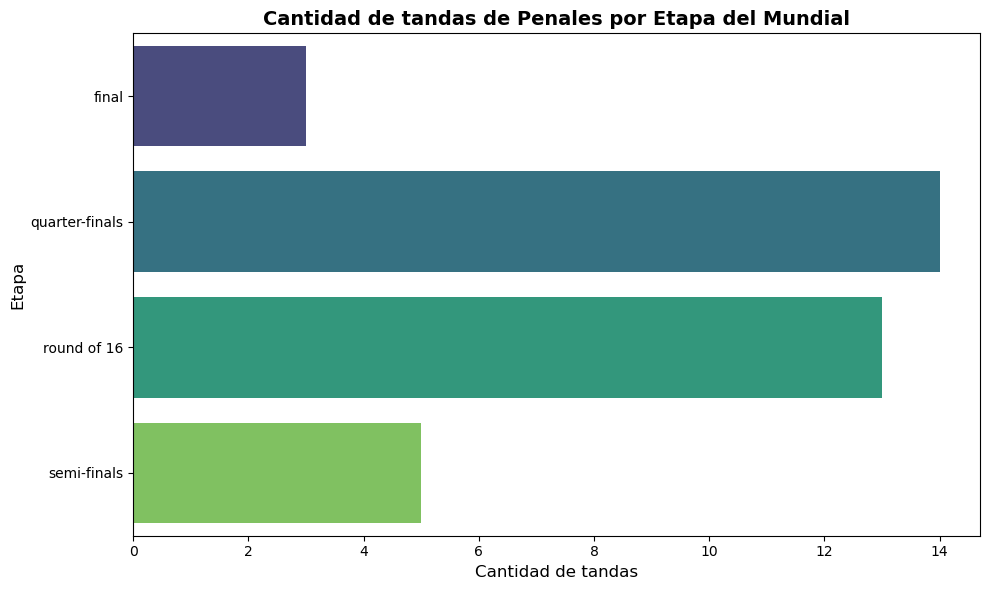

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Cantidad de tandas",
    y="Etapa",
    data=tandas_etapa,
    palette="viridis"
)

plt.title("Cantidad de tandas de Penales por Etapa del Mundial", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de tandas", fontsize=12)
plt.ylabel("Etapa", fontsize=12)

plt.tight_layout()
plt.show()

Los cuartos de final concentran la mayor cantidad de tandas de penales. Cabe aclarar, que las finales presentan menos tandas porque naturalmente, hay menor cantidad de partidos disputados, asi como las tandas solo aparecen en fases eliminatorias.

In [16]:
efectividad_etapa = penales.groupby("stage_name")["converted"].mean().round(4).reset_index()
efectividad_etapa.columns = ["Etapa", "Conversion"]
efectividad_etapa["Conversion"] = efectividad_etapa["Conversion"] * 100
efectividad_etapa = efectividad_etapa.sort_values(by="Conversion", ascending=False)

print(efectividad_etapa)

            Etapa  Conversion
3     semi-finals       76.09
0           final       73.08
1  quarter-finals       70.99
2     round of 16       64.10


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\3401562560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  efectividad_etapa = penales.groupby("stage_name")["converted"].mean().round(4).reset_index()


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\1905156015.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


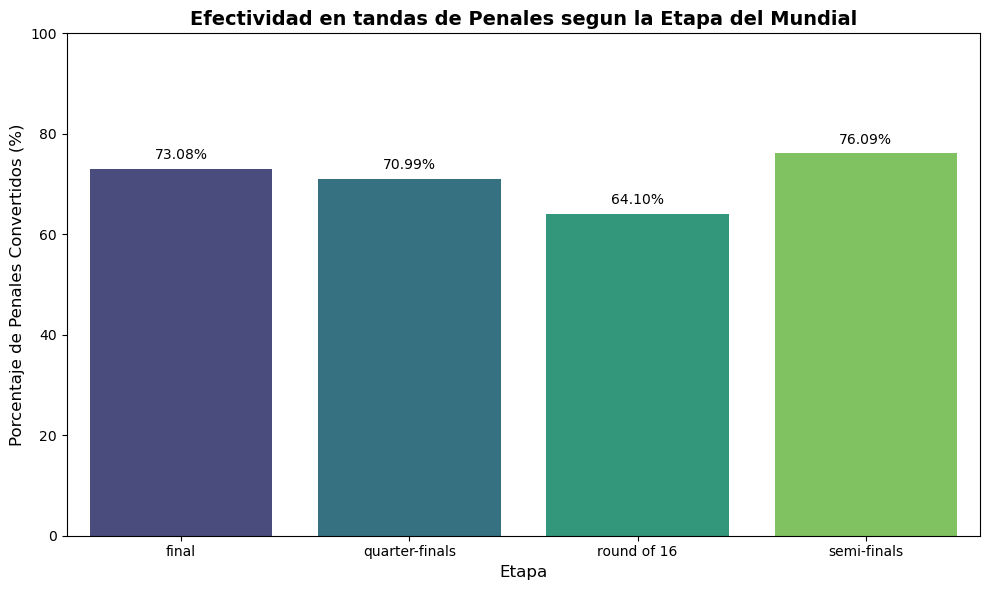

In [17]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x="Etapa",
    y="Conversion",
    data=efectividad_etapa,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%', 
        padding=5
    )

plt.title("Efectividad en tandas de Penales segun la Etapa del Mundial", fontsize=14, fontweight='bold')
plt.xlabel("Etapa", fontsize=12)
plt.ylabel("Porcentaje de Penales Convertidos (%)", fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

La efectividad está entre el 64% y el 76% según la etapa. La instancia con menor conversión es la ronda de dieciseisavos. No hay una gran diferencia entre etapas.

In [18]:
tabla_auxiliar1 = penales.groupby("stage_name")["converted"].agg(["count", "mean"]).reset_index()
tabla_auxiliar1.columns = ["Etapa", "Lanzamientos", "Conversion"]
tabla_auxiliar1 = tabla_auxiliar1.sort_values(by="Lanzamientos", ascending=False)
print(tabla_auxiliar1)

            Etapa  Lanzamientos  Conversion
1  quarter-finals           131    0.709924
2     round of 16           117    0.641026
3     semi-finals            46    0.760870
0           final            26    0.730769


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\4050763167.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_auxiliar1 = penales.groupby("stage_name")["converted"].agg(["count", "mean"]).reset_index()


In [19]:
penales["converted"].mean()

np.float64(0.69375)

Los datos no sugieren que haya una caída en las instancias más competitivas. Las semifinales y finales tienen mayor tasa de conversión, pero las dos etapas son las que menor cantidad de lanzamientos tienen. La única instancia que está por debajo del promedio global son los octavos.

## Evolución histórica

In [20]:
evolucion_mundiales = penales.groupby("year")["converted"].mean().reset_index()
evolucion_mundiales.columns = ["Mundial", "Efectividad"]
evolucion_mundiales["Efectividad"] = evolucion_mundiales["Efectividad"] * 100
evolucion_mundiales = evolucion_mundiales.sort_values(by="Mundial")

print(evolucion_mundiales)

    Mundial  Efectividad
0      1982    75.000000
1      1986    77.777778
2      1990    73.684211
3      1994    62.068966
4      1998    71.428571
5      2002    68.421053
6      2006    63.636364
7      2010    77.777778
8      2014    72.222222
9      2018    66.666667
10     2022    63.414634


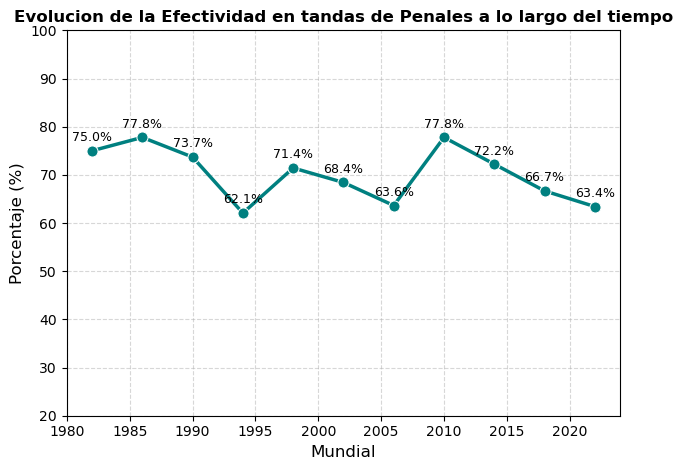

In [21]:
sns.lineplot(
    x="Mundial",
    y="Efectividad",
    data=evolucion_mundiales,
    marker="o",
    markersize=8,
    color="teal",
    linewidth=2.5
)

for i in range(len(evolucion_mundiales)):
    plt.text(
        x=evolucion_mundiales["Mundial"].iloc[i],
        y=evolucion_mundiales["Efectividad"].iloc[i]+2,
        s=f'{evolucion_mundiales["Efectividad"].iloc[i]:.1f}%', 
        ha='center', 
        fontsize=9, 
    )


plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Evolucion de la Efectividad en tandas de Penales a lo largo del tiempo", fontweight="bold")
plt.xlabel("Mundial", fontsize=12)
plt.ylabel("Porcentaje (%)", fontsize=12)
plt.ylim(20, 100)

plt.tight_layout()
plt.show()

Se puede observar a partir de este gráfico que la efectividad en la historia se mantuvo entre el intervalo de 62% a 78% aproximadamente. Lo que resulta interesante, es que desde 2010, la efectividad tiene un comportamiento decreciente. El mundial de Qatar 2022 está en el top 3 de porcentaje de conversión más bajo en partidos definidos por tandas de penales. 

In [22]:
frecuencia_tandas = partidos.groupby("year")["penalty_shootout"].agg(["sum", "mean"]).reset_index()
frecuencia_tandas.columns = ["Año", "Cantidad de tandas", "Porcentaje"]
frecuencia_tandas["Porcentaje"] = frecuencia_tandas["Porcentaje"] * 100
frecuencia_tandas = frecuencia_tandas.sort_values(by="Año")

print(frecuencia_tandas)

     Año  Cantidad de tandas  Porcentaje
0   1930                   0    0.000000
1   1934                   0    0.000000
2   1938                   0    0.000000
3   1950                   0    0.000000
4   1954                   0    0.000000
5   1958                   0    0.000000
6   1962                   0    0.000000
7   1966                   0    0.000000
8   1970                   0    0.000000
9   1974                   0    0.000000
10  1978                   0    0.000000
11  1982                   1    1.923077
12  1986                   3    5.769231
13  1990                   4    7.692308
14  1994                   3    5.769231
15  1998                   3    4.687500
16  2002                   2    3.125000
17  2006                   4    6.250000
18  2010                   2    3.125000
19  2014                   4    6.250000
20  2018                   4    6.250000
21  2022                   5    7.812500


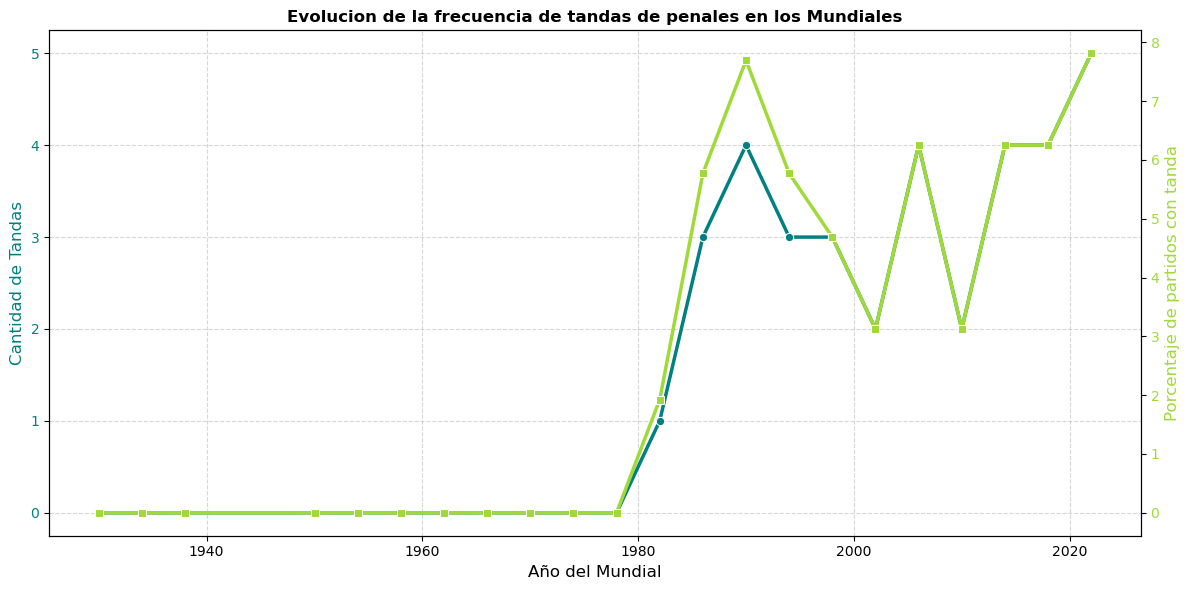

In [23]:
fig, ax1 = plt.subplots(figsize=(12, 6))

plt.grid(True, linestyle='--', alpha=0.5)

ax1.set_xlabel('Año del Mundial', fontsize=12)
ax1.set_ylabel('Cantidad de Tandas', color='teal', fontsize=12)

sns.lineplot(
    x="Año",
    y="Cantidad de tandas",
    data=frecuencia_tandas,
    marker="o",
    color='teal',
    linewidth=2.5,
    ax=ax1
)

ax1.tick_params(axis='y', labelcolor='teal')

ax2= ax1.twinx()
ax2.set_ylabel('Porcentaje de partidos con tanda', color='#a0da39', fontsize=12)

sns.lineplot(
    x="Año",
    y="Porcentaje",
    data=frecuencia_tandas,
    marker="s",
    color='#a0da39',
    linewidth=2.5,
    ax=ax2
)

ax2.tick_params(axis='y', labelcolor='#a0da39')

plt.title("Evolucion de la frecuencia de tandas de penales en los Mundiales", fontsize=12, fontweight='bold')

fig.tight_layout()
plt.show()


De 1930 a 1978 las líneas son planas en cero porque las tandas de penales no existían. A partir de 1982 la curva se agranda, con un pico en 1990 con 4 tandas de penales. Desde 2006 en adelante, se estabilizó. Se puede concluir, que las tandas son un fenómeno frecuente y consolidado en el fútbol.

Acercándose a la actualidad, las líneas se superponen porque se cambió el formato a 32 equipos y 64 partidos, por lo que la relación matemática cambió. El denominador cambiaba antes.


In [24]:
analisis_var = partidos[["match_id", "year"]].copy()

penales_por_partido = (goles[goles["penalty"]].groupby("match_id").size())

analisis_var["cantidad_penales"] = (analisis_var["match_id"].map(penales_por_partido)).fillna(0)

analisis_var["Era"] = np.where(analisis_var["year"] >= 2018,
                               "Era VAR",
                               "Pre-VAR"
                               )

tabla_resumen_var = (analisis_var.groupby("Era").agg(
    Partidos=("match_id", "count"),
    Penales_totales=("cantidad_penales", "sum"),
    Penales_por_partido=("cantidad_penales", "mean")
).reset_index())


print(tabla_resumen_var)

       Era  Partidos  Penales_totales  Penales_por_partido
0  Era VAR       128             39.0             0.304688
1  Pre-VAR       836            175.0             0.209330


La integración del VAR fue en el 2018. Por lo que la era VAR constituye únicamente los Mundiales de los años 2018 y 2022. Aun así, con solo 128 partidos, tiene aproximadamente un 10% más de penales por partido que la era Pre-VAR. Esta es la prueba de que las revisiones en video hicieron que se cobren más penales por encuentro.

## Países

In [25]:
goles_penal = goles[goles["penalty"]==True]
top_penales_pais = goles_penal.groupby("team_name").size().reset_index(name="Cantidad de penales")
top_10_penales_pais = top_penales_pais.sort_values(by="Cantidad de penales", ascending=False).head(10)
print(top_10_penales_pais)

       team_name  Cantidad de penales
68         Spain                   16
25        France                   15
2      Argentina                   12
24       England                   12
41        Mexico                   10
8         Brazil                   10
43   Netherlands                   10
53      Portugal                    9
79  West Germany                    9
36         Italy                    8


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\4260169320.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_penales_pais = goles_penal.groupby("team_name").size().reset_index(name="Cantidad de penales")


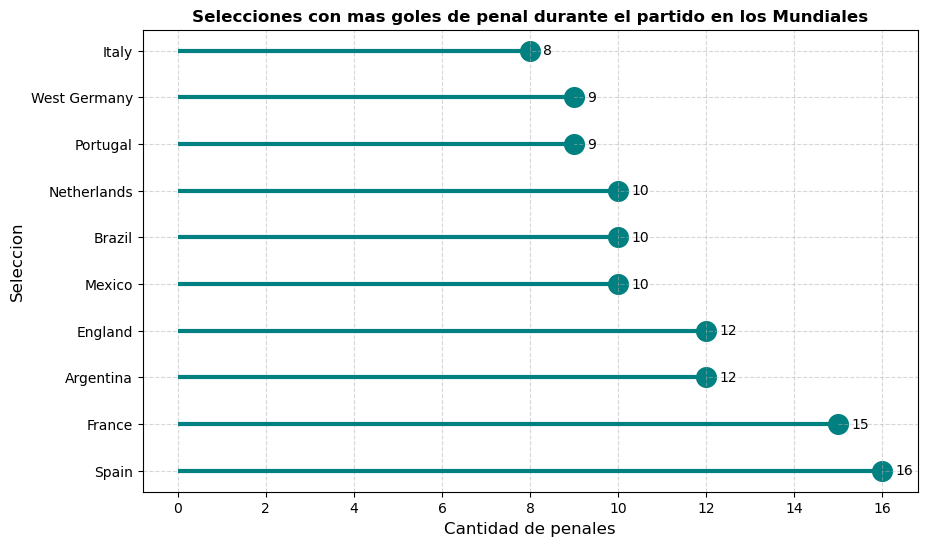

In [26]:
plt.figure(figsize=(10, 6))

plt.hlines(
    y=top_10_penales_pais["team_name"],
    xmin=0,
    xmax=top_10_penales_pais["Cantidad de penales"],
    color="teal",
    linewidth=3
)

plt.scatter(
    x=top_10_penales_pais["Cantidad de penales"],
    y=top_10_penales_pais["team_name"],
    color="teal",
    s=200
)

for i, valor in enumerate(top_10_penales_pais["Cantidad de penales"]):
    plt.text(
        x=valor + 0.3,
        y=i,
        s=str(valor),
        va="center"
    )

plt.grid(True, linestyle='--', alpha=0.5)

plt.title("Selecciones con mas goles de penal durante el partido en los Mundiales", fontsize=12, fontweight="bold")
plt.xlabel("Cantidad de penales", fontsize=12)
plt.ylabel("Seleccion", fontsize=12)

plt.show()

In [27]:
tabla_paises = penales.groupby("team_name")["converted"].agg(["count", "mean"]).reset_index()
tabla_paises.columns = ["Seleccion", "Lanzamientos", "Efectividad"]
tabla_paises["Efectividad"] = (tabla_paises["Efectividad"] * 100).round(2)
top_10_lanza = tabla_paises.sort_values(by="Lanzamientos", ascending=False).head(10)

print(top_10_lanza)

       Seleccion  Lanzamientos  Efectividad
0      Argentina            31        80.65
10        France            24        70.83
2         Brazil            22        68.18
25         Spain            22        59.09
14         Italy            20        65.00
9        England            19        57.89
7        Croatia            18        77.78
18   Netherlands            17        64.71
30  West Germany            14        92.86
22       Romania            11        72.73


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\2361629490.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_paises = penales.groupby("team_name")["converted"].agg(["count", "mean"]).reset_index()


In [28]:
selecciones_efectividad = tabla_paises.sort_values(by="Efectividad", ascending=True)

print(selecciones_efectividad)

              Seleccion  Lanzamientos  Efectividad
27          Switzerland             3         0.00
16               Mexico             7        28.57
31           Yugoslavia             5        40.00
4                 Chile             5        40.00
8               Denmark             5        40.00
12                Ghana             4        50.00
15                Japan             8        50.00
9               England            19        57.89
25                Spain            22        59.09
5              Colombia             5        60.00
20             Portugal             5        60.00
18          Netherlands            17        64.71
14                Italy            20        65.00
2                Brazil            22        68.18
21  Republic of Ireland            10        70.00
10               France            24        70.83
22              Romania            11        72.73
28              Ukraine             4        75.00
13               Greece        

C:\Users\USer\AppData\Local\Temp\ipykernel_16068\2574826410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax6 =sns.barplot(


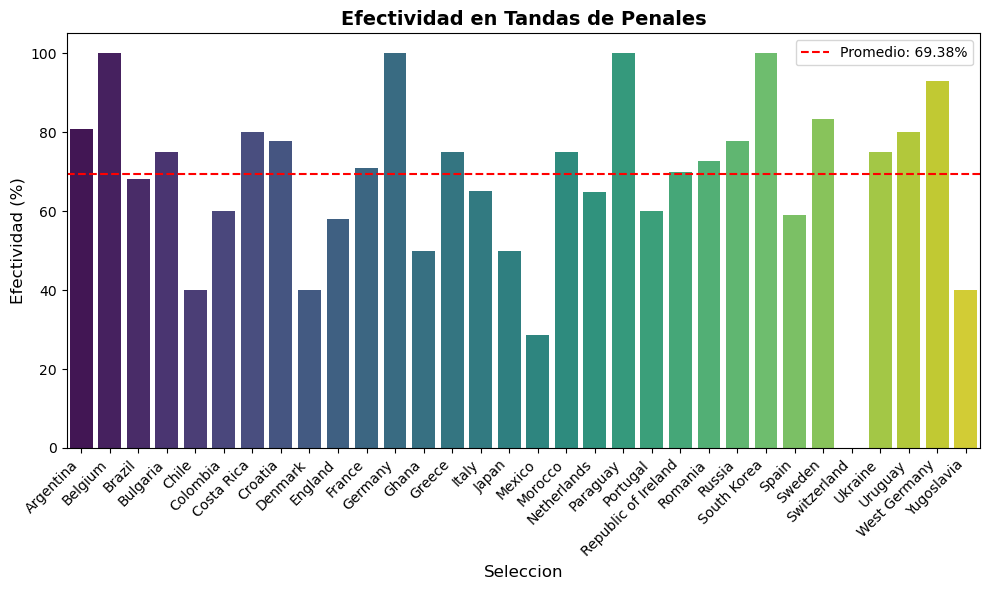

In [29]:
plt.figure(figsize=(10, 6))

ax6 =sns.barplot(
    x="Seleccion",
    y="Efectividad",
    data=selecciones_efectividad,
    palette="viridis"
)

promedio_conversion_global = penales["converted"].mean() * 100

plt.axhline(
    y=promedio_conversion_global,
    color="red",
    linestyle="--",
    label=f'Promedio: {promedio_conversion_global:.2f}%'
)

plt.title("Efectividad en Tandas de Penales", fontsize=14, fontweight='bold')
plt.xlabel("Seleccion", fontsize=12)
plt.ylabel("Efectividad (%)", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.legend()


plt.tight_layout()
plt.show()

El promedio histórico es 69,38%. Varias selecciones superan este valor, pero hay que aclarar que algunas lo hacen con una cantidad pequeña de penales.
Argentina, Croacia y Francia presentan porcentajes de conversión superiores al promedio con una combinación de participación considerable. En contraste, Inglaterra y España, tienen un rendimiento por debajo del promedio.

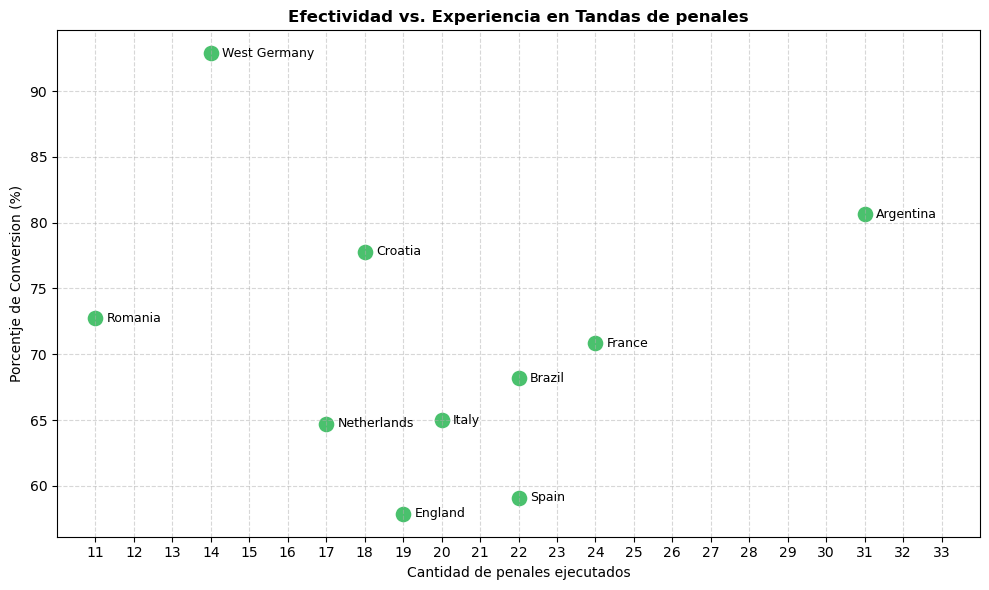

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Lanzamientos",
    y="Efectividad",
    data=top_10_lanza,
    s=150,
    color="#4ac16d",
    )

for i in range(len(top_10_lanza)):
    plt.text(
        x=top_10_lanza["Lanzamientos"].iloc[i] + 0.3,
        y=top_10_lanza["Efectividad"].iloc[i],
        s=top_10_lanza["Seleccion"].iloc[i],
        va="center",
        fontsize=9
    )

min_x = int(top_10_lanza["Lanzamientos"].min())
max_x = int(top_10_lanza["Lanzamientos"].max())
plt.xticks(range(min_x, max_x + 3))
plt.xlim(min_x - 1, max_x + 3)

plt.title("Efectividad vs. Experiencia en Tandas de penales", fontsize=12, fontweight="bold")
plt.xlabel("Cantidad de penales ejecutados")
plt.ylabel("Porcentje de Conversion (%)")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


No se observa una relación entre la cantidad de penales ejecutados y la efectividad. Es decir, la experiencia por sí sola no garantiza un mayor porcentaje de conversión.
Argentina destaca por combinar estas dos dimensiones, con 31 ejecuciones y una tasa de conversión de aproximadamente 80%. Croacia es una selección que presenta uno de los mejores equilibrios. Pero por el otro lado, Inglaterra aparece como uno de los países con una tasa de conversión muy baja.

In [31]:
partidos_tandas = partidos[partidos["penalty_shootout"] == True]

def averiguar_ganador_tanda(row):
    if row["home_team_win"]:
        return row["home_team_name"]
    elif row["away_team_win"]:
        return row["away_team_name"]

partidos_tandas["Ganador Tanda"] = partidos_tandas.apply(averiguar_ganador_tanda, axis=1)

tabla_ganadores_tandas = partidos_tandas["Ganador Tanda"].value_counts().reset_index()

locales = partidos_tandas[["home_team_name", "Ganador Tanda"]]
locales.columns = ["Pais", "Ganador Tanda"]

visitantes = partidos_tandas[["away_team_name", "Ganador Tanda"]]
visitantes.columns = ["Pais", "Ganador Tanda"]

todas_las_tandas = pd.concat([locales, visitantes], ignore_index=True)

todas_las_tandas["Disputadas"] = 1
todas_las_tandas["Ganadas"] = (todas_las_tandas["Pais"] == todas_las_tandas["Ganador Tanda"]).astype(int)

tandas_equipo = todas_las_tandas.groupby("Pais")[["Disputadas", "Ganadas"]].sum().reset_index()
tandas_equipo = tandas_equipo.sort_values(by="Disputadas", ascending=False)

print(tandas_equipo.head(10).to_string(index=False))

        Pais  Disputadas  Ganadas
   Argentina           7        6
      Brazil           5        3
       Spain           5        1
      France           5        2
       Italy           4        1
     Croatia           4        4
     England           4        1
 Netherlands           4        1
West Germany           3        3
      Russia           2        1


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\1031018732.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  partidos_tandas["Ganador Tanda"] = partidos_tandas.apply(averiguar_ganador_tanda, axis=1)


Con esto podemos confirmar el equilibro de Croacia y Alemania, y el caso de Argentina que es la selección que tiene más casos en la tanda de penales.

## Jugadores

In [32]:
tabla_jugadores = penales.groupby("player_name")["converted"].agg(["count", "mean"]).reset_index()
tabla_jugadores.columns = ["Jugador", "Lanzamientos", "Efectividad"]
tabla_jugadores["Efectividad"] = (tabla_jugadores["Efectividad"] * 100).round(2)
top_10_jugadores = tabla_jugadores.sort_values(by="Lanzamientos", ascending=False)

print(top_10_jugadores)

                Jugador  Lanzamientos  Efectividad
150         Luka Modrić             3       100.00
142        Lionel Messi             3       100.00
212      Roberto Baggio             3        66.67
85   Giancarlo González             2       100.00
50      David Trezeguet             2        50.00
..                  ...           ...          ...
107    Jordan Henderson             1         0.00
109     Jorge Rodríguez             1         0.00
110       Josip Pivarić             1         0.00
111        José Holebas             1       100.00
280       Óscar Cardozo             1       100.00

[281 rows x 3 columns]


In [33]:
goles_penal = goles[goles["penalty"]==True]
top_penales_jugador = goles_penal.groupby("player_name").size().reset_index(name="Cantidad de penales")
top_10_penales_jugador = top_penales_jugador.sort_values(by="Cantidad de penales", ascending=False).head(10)
print(top_10_penales_jugador)

                player_name  Cantidad de penales
115         Rob Rensenbrink                    4
150  not applicable Eusébio                    4
89             Lionel Messi                    4
48        Gabriel Batistuta                    4
59               Harry Kane                    4
11        Antoine Griezmann                    3
103            Mile Jedinak                    3
72           Johan Neeskens                    3
39          Fernando Hierro                    3
22        Cristiano Ronaldo                    3


C:\Users\USer\AppData\Local\Temp\ipykernel_16068\1359183576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


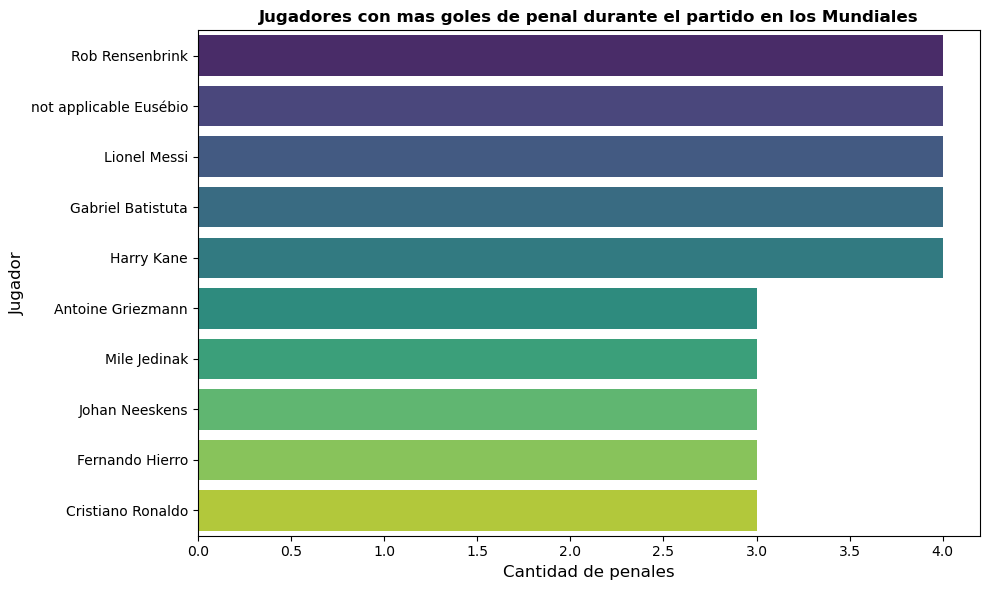

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Cantidad de penales",
    y="player_name",
    data=top_10_penales_jugador,
    palette="viridis"
)

plt.title("Jugadores con mas goles de penal durante el partido en los Mundiales", fontsize=12, fontweight="bold")
plt.xlabel("Cantidad de penales", fontsize=12)
plt.ylabel("Jugador", fontsize=12)

plt.tight_layout()
plt.show()

- - - 
## Conclusiones mirando al Mundial 2026
A partir del análisis en cada sección, se puede hacer las siguientes conclusiones:

Sobre las tendencias históricas, las tandas de penales son cada vez más frecuentes, y la efectividad fue estable a lo largo del tiempo, pero en la última década, es decreciente. También, la introducción del VAR definitivamente incrementó los penales cobrados durante el partido.

Pasando a la presión, las instancias avanzadas no afectan la efectividad. La presión por sí sola no explica las diferencias observadas.

De los países, algunas reputaciones históricas tienen respaldo estadístico significativo. Y sobre los jugadores, la experiencia individual no garantiza mayor tasa de conversión. Los porcentajes extremos se explican por la poca cantidad de lanzamientos.


In [35]:
individual = penales.groupby("team_name")["converted"].agg(["count", "mean"]).reset_index()
individual.columns = ["Pais", "Penales ejecutados", "Porcentaje conversion"]
individual["Porcentaje conversion"] = (individual["Porcentaje conversion"] * 100).round(2)

ranking_completo = pd.merge(individual, tandas_equipo[["Pais", "Ganadas"]], on="Pais", how="left")
ranking_completo["Ganadas"] = ranking_completo["Ganadas"].fillna(0).astype(int)

ranking_final = ranking_completo.sort_values(
    by=["Ganadas", "Porcentaje conversion"], 
    ascending=[False, False]
)

top_ranking = ranking_final.head(15)

print(top_ranking.to_string(index=False))

        Pais  Penales ejecutados  Porcentaje conversion  Ganadas
   Argentina                  31                  80.65        6
     Croatia                  18                  77.78        4
West Germany                  14                  92.86        3
      Brazil                  22                  68.18        3
      France                  24                  70.83        2
     Belgium                   5                 100.00        1
     Germany                   4                 100.00        1
    Paraguay                   5                 100.00        1
 South Korea                   5                 100.00        1
      Sweden                   6                  83.33        1
  Costa Rica                  10                  80.00        1
     Uruguay                   5                  80.00        1
      Russia                   9                  77.78        1
    Bulgaria                   4                  75.00        1
     Morocco             

C:\Users\USer\AppData\Local\Temp\ipykernel_16068\4241610022.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  individual = penales.groupby("team_name")["converted"].agg(["count", "mean"]).reset_index()


Para finalizar este análisis, un ranking de las selecciones que cara al Mundial 2026 tienen buen historial desde el punto a patear el penal. Las diferencias pueden sugerir que la experiencia colectiva del equipo y la tradición en este tipo de definiciones pueden desempeñar un papel muy importante. Argentina, Croacia, Alemania son los mejores respaldados.